load data

In [3]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

record = wfdb.rdrecord("100", pn_dir="mitdb")
signal = record.p_signal[:, 0]
fs = record.fs

filter ECG

In [4]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, fs, low=0.5, high=40):
    nyquist = 0.5 * fs
    low /= nyquist
    high /= nyquist
    b, a = butter(4, [low, high], btype='band')
    return filtfilt(b, a, signal)

filtered_ecg = bandpass_filter(signal, fs)

dêtct R-peaks

In [5]:
from wfdb import processing

r_peaks = processing.gqrs_detect(sig=filtered_ecg, fs=fs)

RR intervals

In [6]:
rr_intervals = np.diff(r_peaks) / fs

Heart Rate (BPM)

In [7]:
heart_rate = 60 / rr_intervals

Heart rate time series

In [8]:
rr_times = r_peaks[1:] / fs
hr_series = pd.Series(heart_rate, index=rr_times)

print(hr_series.head())

1.805556    73.720137
2.594444    76.056338
3.383333    76.056338
4.172222    76.056338
4.991667    73.220339
dtype: float64


train test spilt

In [9]:
train_size = int(len(hr_series) * 0.7)
train = hr_series.iloc[:train_size]
test = hr_series.iloc[train_size:]

train arima

In [10]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(3,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided

plot forecast

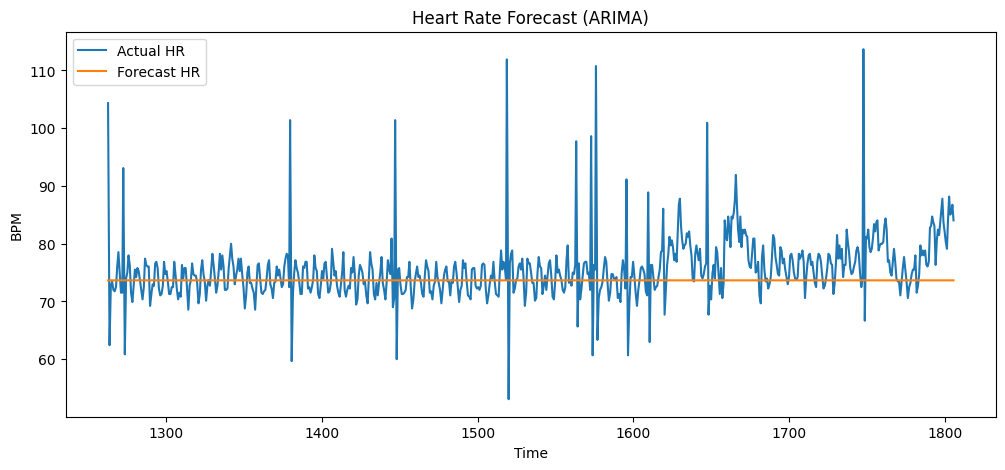

In [10]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Actual HR")
plt.plot(test.index, forecast, label="Forecast HR")
plt.legend()
plt.title("Heart Rate Forecast (ARIMA)")
plt.xlabel("Time")
plt.ylabel("BPM")
plt.show()

model selection

In [14]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

orders = [(1,1,1), (2,1,1), (2,1,2), (3,1,1), (3,1,2), (4,1,1), (4, 1, 2), (4, 1, 3), (3, 1, 3)]

results = []

for order in orders:
    model = ARIMA(train, order=order)
    model_fit = model.fit()
    
    forecast = model_fit.forecast(steps=len(test))
    
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mae = mean_absolute_error(test, forecast)
    
    results.append([order, rmse, mae, model_fit.aic, model_fit.bic])

results_df = pd.DataFrame(results, columns=["ARIMA(p,d,q)", "RMSE", "MAE", "AIC", "BIC"])

print(results_df.sort_values(by="RMSE"))

c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided

  ARIMA(p,d,q)      RMSE       MAE          AIC          BIC
8    (3, 1, 3)  5.772910  3.640272  9402.347261  9439.938876
0    (1, 1, 1)  5.777446  3.644306  9398.616013  9414.726705
2    (2, 1, 2)  5.779825  3.646347  9402.521562  9429.372716
6    (4, 1, 2)  5.790674  3.655614  9229.800678  9267.392293
7    (4, 1, 3)  5.791459  3.644087  9120.099033  9163.060878
1    (2, 1, 1)  5.793011  3.657806  9399.726474  9421.207397
4    (3, 1, 2)  5.805370  3.671660  9288.646616  9320.868000
3    (3, 1, 1)  5.834950  3.693606  9388.964206  9415.815359
5    (4, 1, 1)  5.852419  3.709872  9346.958869  9379.180253


c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception

c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


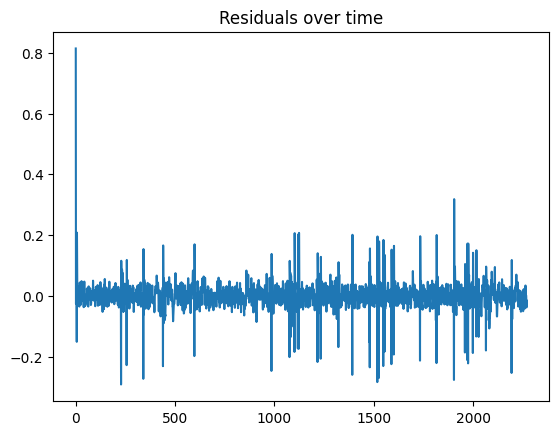

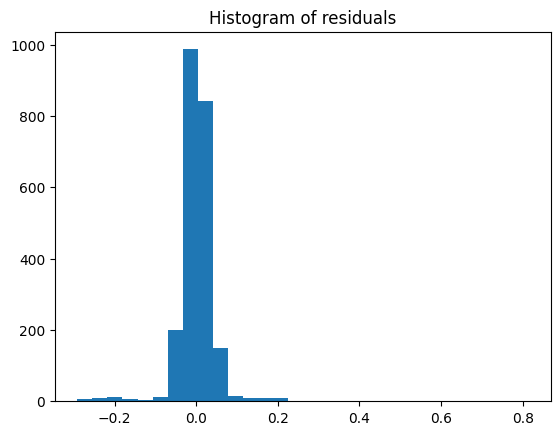

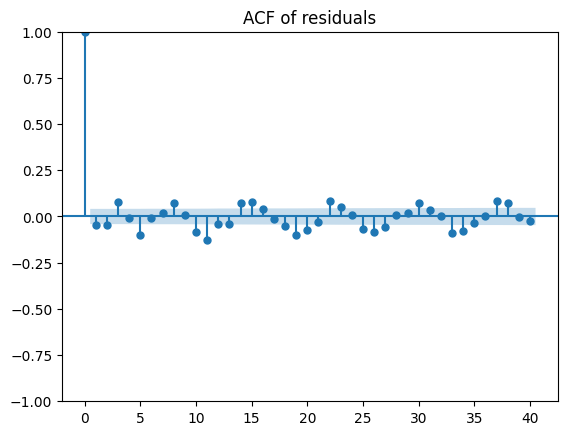

In [15]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

model = sm.tsa.ARIMA(rr_intervals, order=(4,1,3))
result = model.fit()

residuals = result.resid

# Residual plot
plt.figure()
plt.plot(residuals)
plt.title("Residuals over time")
plt.show()

# Histogram
plt.figure()
plt.hist(residuals, bins=30)
plt.title("Histogram of residuals")
plt.show()

# ACF residual
sm.graphics.tsa.plot_acf(residuals, lags=40)
plt.title("ACF of residuals")
plt.show()

In [16]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb_test)

      lb_stat     lb_pvalue
10  77.234617  1.744854e-12
